# 04_lstm.ipynb
## LSTM Model for Web Traffic Forecasting (60-Day Horizon)

This notebook loads the engineered feature dataset from Notebook 02
and trains a simple LSTM model to forecast the next **60 days** for each page.

**Steps:**
- Load features and labels  
- Create sequences suitable for LSTM  
- Build an LSTM model (TensorFlow / Keras)  
- Train for a small number of epochs  
- Generate predictions  
- Compute SMAPE metric  
- Save outputs for ensemble (Notebook 05)  


## Imports

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os


## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Features + Labels

We load:
- features.csv → lag + rolling + metadata  
- labels.csv → next 60 days (our prediction targets)  


In [3]:
save_dir = "/content/drive/MyDrive/CSC480/Final Project/"

features_path = save_dir + "features.csv"
labels_path = save_dir + "labels.csv"

df_features = pd.read_csv(features_path)
df_labels = pd.read_csv(labels_path)

df_features.head(), df_labels.head()


(                                                Page  2015-07-01  2015-07-02  \
 0  Phabricator/Project_management_www.mediawiki.o...    1.945910    1.945910   
 1  Now_You_See_Me_es.wikipedia.org_desktop_all-ag...    5.493061    5.605802   
 2  Zürich_Hackathon_2014_www.mediawiki.org_all-ac...    1.386294    2.995732   
 3       Érythrée_fr.wikipedia.org_desktop_all-agents    6.511745    6.242223   
 4   Metallica_es.wikipedia.org_all-access_all-agents    7.336286    7.405496   
 
    2015-07-03  2015-07-04  2015-07-05  2015-07-06  2015-07-07  2015-07-08  \
 0    1.609438    1.945910    2.197225    1.945910    1.609438    0.000000   
 1    5.736572    5.429346    5.774552    5.743003    5.493061    5.468060   
 2    2.995732    3.433987    3.091042    3.218876    2.890372    5.187386   
 3    6.652863    7.060476    6.304449    6.628041    6.320768    6.204558   
 4    7.441320    7.358831    7.336286    7.363914    7.383368    7.457032   
 
    2015-07-09  ...  2016-12-25_roll_std  

## LSTM Input Format

LSTM expects data in the format:

**(samples, timesteps, features)**

We will reshape the engineered features into:

- timesteps = 1  
- features = all numeric columns  

This gives the LSTM the ability to process all input features per page.


In [4]:
# Select numeric feature columns
X = df_features.select_dtypes(include=[np.number]).values
y = df_labels.values  # shape: (samples, 60)

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)

# LSTM expects 3D: (samples, timesteps=1, features)
X_lstm = np.expand_dims(X, axis=1)

print("Reshaped X for LSTM:", X_lstm.shape)


Original X shape: (500, 3303)
Original y shape: (500, 60)
Reshaped X for LSTM: (500, 1, 3303)


## LSTM Model Architecture

We use a simple architecture:
- LSTM(64)  
- Dropout(0.2) to avoid overfitting  
- Dense(60) output layer (one value per day in forecast)  


In [5]:
model = Sequential([
    LSTM(64, input_shape=(1, X.shape[1])),
    Dropout(0.2),
    Dense(60)  # output horizon
])

model.compile(optimizer='adam', loss='mae')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │       862,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60)             │         3,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 866,108 (3.30 MB)

 Trainable params: 866,108 (3.30 MB)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM Model

We train for a small number of epochs (e.g., 5) due to limited time/resources.

This is enough for a baseline forecast used in ensemble.


Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: nan - val_loss: nan
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: nan - val_loss: nan
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: nan - val_loss: nan
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: nan - val_loss: nan
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: nan - val_loss: nan


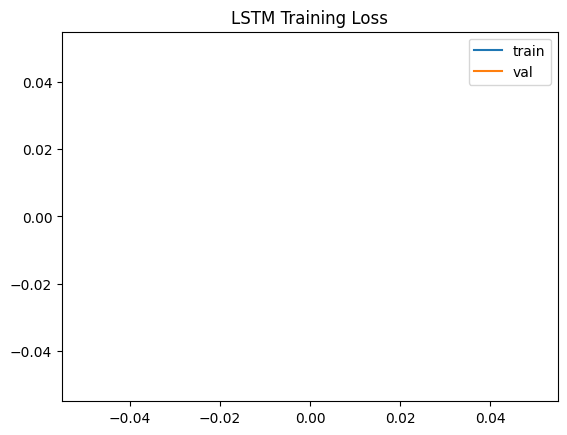

In [6]:
history = model.fit(
    X_lstm, y,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Plot training curve
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("LSTM Training Loss")
plt.legend()
plt.show()


## Predict the Next 60 Days

We run the model on all LSTM inputs.


In [7]:
lstm_predictions = model.predict(X_lstm)
lstm_predictions.shape


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


(500, 60)

## Compute SMAPE for LSTM


In [8]:
def smape(true, pred):
    numer = np.abs(true - pred)
    denom = np.abs(true) + np.abs(pred) + 1e-8
    return np.mean(2 * numer / denom)

lstm_smape = smape(y, lstm_predictions)
print("LSTM SMAPE:", lstm_smape)


LSTM SMAPE: nan


## Save LSTM Outputs for Ensemble (Notebook 05)
- lstm_predictions.csv  
- lstm_smape.txt  


In [9]:
save_dir = "/content/drive/MyDrive/CSC480/Final Project/"
os.makedirs(save_dir, exist_ok=True)

# Save predictions
pred_path = save_dir + "lstm_predictions.csv"
np.savetxt(pred_path, lstm_predictions, delimiter=",")

# Save smape score
score_path = save_dir + "lstm_smape.txt"
with open(score_path, "w") as f:
  f.write(str(lstm_smape))

print("Saved LSTM predictions to:", pred_path)
print("Saved LSTM SMAPE score to:", score_path)


Saved LSTM predictions to: /content/drive/MyDrive/CSC480/Final Project/lstm_predictions.csv
Saved LSTM SMAPE score to: /content/drive/MyDrive/CSC480/Final Project/lstm_smape.txt
